In [1]:
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conexión a MongoDB
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["taller4_db"]
collection = db["raw_data"]

# Leer datos
data = list(collection.find())
print(f"Total de documentos: {len(data)}")


Matplotlib is building the font cache; this may take a moment.


Total de documentos: 826


In [2]:
# Selección de 5 variables relevantes
df = pd.DataFrame([{
    "nombre": char["name"],
    "estado": char["status"],
    "especie": char["species"],
    "genero": char["gender"],
    "origen": char["origin"]["name"],
    "episodios": len(char["episode"])
} for char in data])

# Inspección básica
print(df.head())
print("\n")
print(df.info())
print("\n")
print("Valores nulos:")
print(df.isnull().sum())

         nombre estado especie  genero                         origen  \
0  Rick Sanchez  Alive   Human    Male                  Earth (C-137)   
1   Morty Smith  Alive   Human    Male                        unknown   
2  Summer Smith  Alive   Human  Female  Earth (Replacement Dimension)   
3    Beth Smith  Alive   Human  Female  Earth (Replacement Dimension)   
4   Jerry Smith  Alive   Human    Male  Earth (Replacement Dimension)   

   episodios  
0         51  
1         51  
2         42  
3         42  
4         39  


<class 'pandas.DataFrame'>
RangeIndex: 826 entries, 0 to 825
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   nombre     826 non-null    str  
 1   estado     826 non-null    str  
 2   especie    826 non-null    str  
 3   genero     826 non-null    str  
 4   origen     826 non-null    str  
 5   episodios  826 non-null    int64
dtypes: int64(1), str(5)
memory usage: 38.8 KB
None


Valores nulos:
nom

In [3]:
# INSIGHTS NUMÉRICOS

# 1. Conteo por estado
print("1. Personajes por estado:")
print(df["estado"].value_counts())

# 2. Personaje con más episodios
print("\n2. Personaje con más episodios:")
idx = df["episodios"].idxmax()
print(f"   {df.loc[idx, 'nombre']} con {df.loc[idx, 'episodios']} episodios")

# 3. Especie más común
print("\n3. Especie más común:")
print(f"   {df['especie'].value_counts().index[0]} con {df['especie'].value_counts().iloc[0]} personajes")

# 4. Promedio de episodios por personaje
print("\n4. Promedio de episodios por personaje:")
print(f"   {df['episodios'].mean():.2f} episodios")

# 5. Conteo por género
print("\n5. Personajes por género:")
print(df["genero"].value_counts())

1. Personajes por estado:
estado
Alive      439
Dead       287
unknown    100
Name: count, dtype: int64

2. Personaje con más episodios:
   Rick Sanchez con 51 episodios

3. Especie más común:
   Human con 366 personajes

4. Promedio de episodios por personaje:
   1.53 episodios

5. Personajes por género:
genero
Male          610
Female        148
unknown        49
Genderless     19
Name: count, dtype: int64


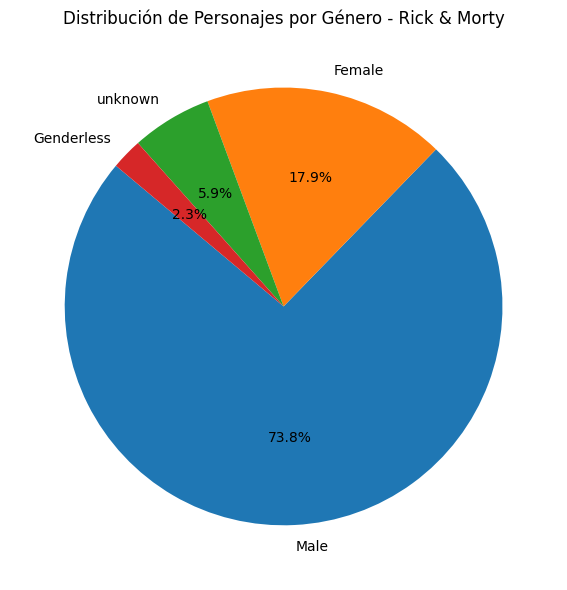

In [4]:
# GRÁFICO 1: Pie Chart - Distribución por género
plt.figure(figsize=(8, 6))
genero_counts = df["genero"].value_counts()
plt.pie(genero_counts, labels=genero_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribución de Personajes por Género - Rick & Morty")
plt.tight_layout()
plt.show()

C:\Users\jonat\AppData\Local\Temp\ipykernel_476\1003010806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=estado_counts.index, y=estado_counts.values, palette="viridis")


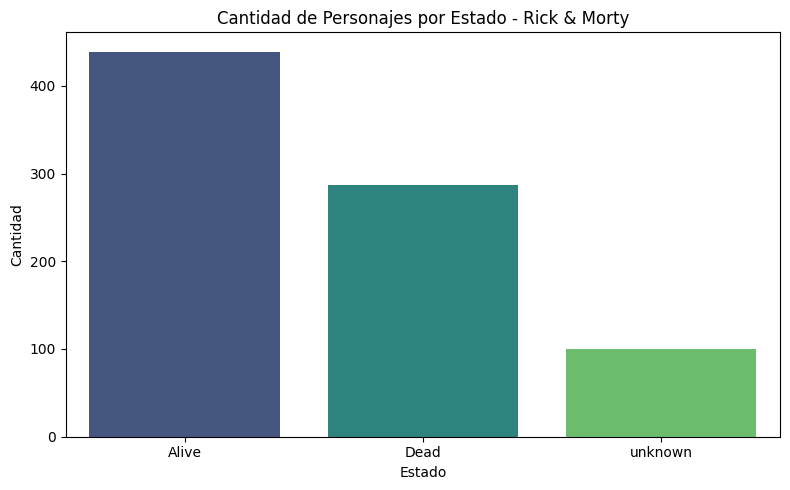

In [5]:
# GRÁFICO 2: Barras - Personajes por estado
plt.figure(figsize=(8, 5))
estado_counts = df["estado"].value_counts()
sns.barplot(x=estado_counts.index, y=estado_counts.values, palette="viridis")
plt.title("Cantidad de Personajes por Estado - Rick & Morty")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

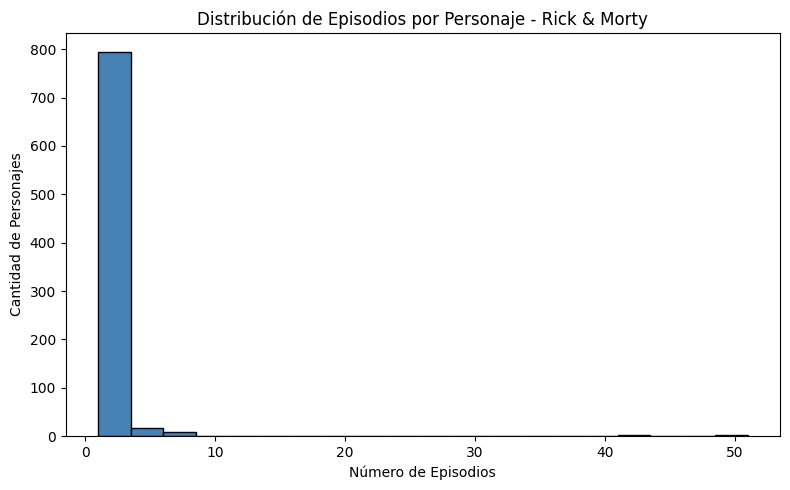

In [6]:
# GRÁFICO 3: Histograma - Distribución de episodios por personaje
plt.figure(figsize=(8, 5))
plt.hist(df["episodios"], bins=20, color="steelblue", edgecolor="black")
plt.title("Distribución de Episodios por Personaje - Rick & Morty")
plt.xlabel("Número de Episodios")
plt.ylabel("Cantidad de Personajes")
plt.tight_layout()
plt.show()

In [ ]:
# CONCLUSIONES DEL ANÁLISIS
print("=== INSIGHTS PRINCIPALES ===")
print(f"1. Total de personajes en Rick & Morty: {len(df)}")
print(f"2. El {round(df['estado'].value_counts()['Alive']/len(df)*100, 1)}% de los personajes están vivos")
print(f"3. El {round(df['genero'].value_counts()['Male']/len(df)*100, 1)}% de los personajes son masculinos")
print(f"4. La especie dominante es Human con {df['especie'].value_counts()['Human']} personajes")
print(f"5. Rick Sanchez es el personaje con más apariciones: 51 episodios")